## 시설 공급 대비 이용 부하 분석
### 질문
- 지하철역별 교통약자 편의시설(EV, ES)의 공급량이 실제 무임 이용 수요를 얼마나 수용하고 있는가?
### 가설
- 단순히 무임승하차인원이 많은 역보다, 시설별 가중치를 반영한 시설부하지수를 적용했을 때 실질적인 이동의 제약이 발생하는 역이 더 객관적으로 식별될 것이다.
### 분석 방법
- 이동 수단별 특성과 교통약자의 의존도를 고려하여 가중치 기반 지수 산출
    - 엘리베이터(EV) 가중치 4: 휠체어 이용자에게 대체 불가능한 필수 이동 수단
    - 에스컬레이터(ES) 가중치 1: 보행 보조 및 흐름 분산 수단으로서의 가치 반영
- 계산식: $시설부하지수 = \frac{무임승하차 인원}{(EV \times 4) + (ES \times 1)}$
- 산출된 지수를 기준으로 내림차순 정렬하여 상위 20%의 역을 선정하고, 막대그래프를 통해 역별 부하 정도를 시각화

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [4]:
base_df = pd.read_csv("../../data/processed/team/subway_merged_base.csv")
base_df

,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수
0,제기동,1,501317,269661,511782,290055,1013099,559716,55.25,3,2,5,39979.71
1,종각,1,1112527,151760,1083408,140929,2195935,292689,13.33,4,2,6,16260.50
2,종로5가,1,712905,247967,697910,240352,1410815,488319,34.61,3,0,3,40693.25
3,청량리,1,662997,280334,656727,281655,1319724,561989,42.58,2,6,8,40142.07
4,강남,2,2302759,161221,2246564,140970,4549323,302191,6.64,4,0,4,18886.94
...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,충무로,"3,4",867520,119883,893846,121889,1761366,241772,13.73,4,23,27,6199.28
240,충정로,"2,5",417744,63616,436275,64124,854019,127740,14.96,4,8,12,5322.50
241,태릉입구,"6,7",438855,87568,443702,85169,882557,172737,19.57,6,24,30,3598.69
242,합정,"2,6",1379809,113748,1461301,111461,2841110,225209,7.93,7,16,23,5118.39


In [29]:
base_df['no_weight_시설부하지수'] = (base_df['무임승하차'] / base_df['TOTAL']).round(2)

In [31]:
base_no_weight_descending_df = base_df.sort_values(by='no_weight_시설부하지수', ascending=False).copy()

index = int(len(base_no_weight_descending_df) * 0.2)

top_20_no_weight_df = base_no_weight_descending_df.iloc[:index].copy()

print(f"전체 역 개수: {len(base_no_weight_descending_df)}")
print(f"상위 20% 역 개수: {len(top_20_no_weight_df)}")
top_20_no_weight_df.head()

전체 역 개수: 244
상위 20% 역 개수: 48


,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수,no_weight_시설부하지수
2,종로5가,1,712905,247967,697910,240352,1410815,488319,34.61,3,0,3,40693.25,162773.00
0,제기동,1,501317,269661,511782,290055,1013099,559716,55.25,3,2,5,39979.71,111943.20
60,홍제,3,530608,146942,503869,144399,1034477,291341,28.16,3,0,3,24278.42,97113.67
65,미아사거리,4,779304,190582,765423,190213,1544727,380795,24.65,2,2,4,38079.50,95198.75
18,선릉,2,1557470,234282,1369726,206084,2927196,440366,15.04,3,2,5,31454.71,88073.20


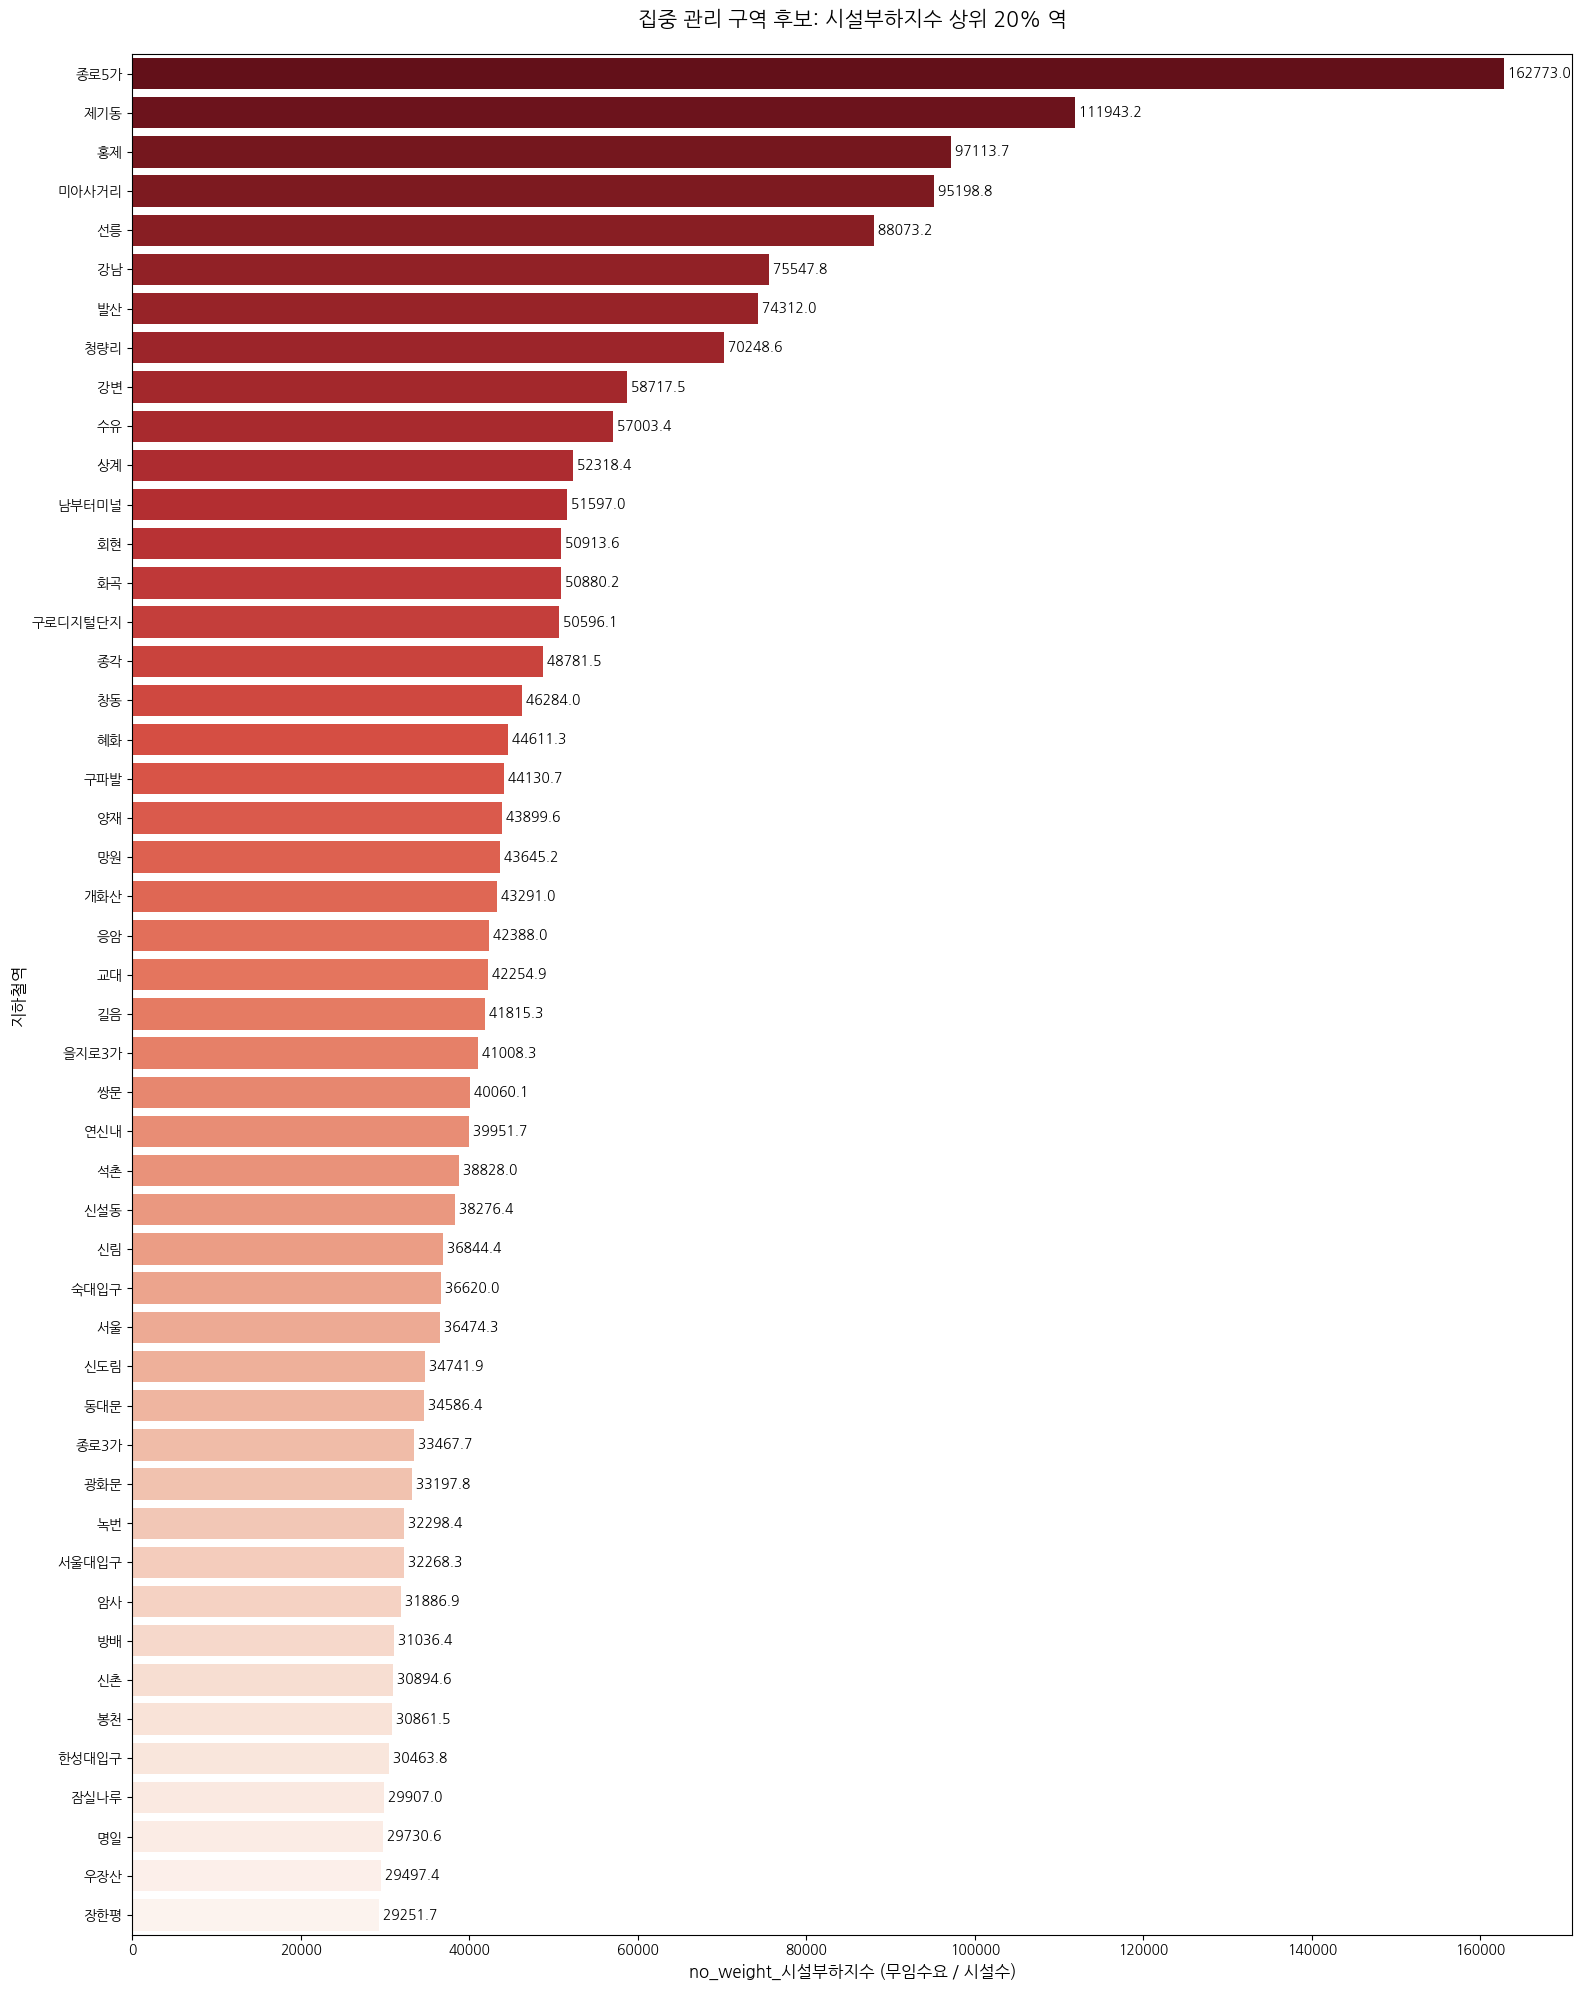

In [38]:
# 가중치 적용 X , 상위 20%역 시각화
plt.figure(figsize=(16, 20))

sns.barplot(
    data=top_20_no_weight_df,
    x='no_weight_시설부하지수',
    y='지하철역',
    hue='지하철역',
    palette='Reds_r',
    legend=False
)

plt.title('집중 관리 구역 후보: 시설부하지수 상위 20% 역', fontsize=15, pad=20)
plt.xlabel('no_weight_시설부하지수 (무임수요 / 시설수)', fontsize=12)
plt.ylabel('지하철역', fontsize=12)

for i, val in enumerate(top_20_no_weight_df['no_weight_시설부하지수']):
    plt.text(val, i, f' {val:.1f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [33]:
base_descending_df = base_df.sort_values(by='시설부하지수', ascending=False).copy()

index = int(len(base_descending_df) * 0.2)

top_20_df = base_descending_df.iloc[:index].copy()

print(f"전체 역 개수: {len(base_descending_df)}")
print(f"상위 20% 역 개수: {len(top_20_df)}")
top_20_df.head()

전체 역 개수: 244
상위 20% 역 개수: 48


,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수,no_weight_시설부하지수
2,종로5가,1,712905,247967,697910,240352,1410815,488319,34.61,3,0,3,40693.25,162773.00
3,청량리,1,662997,280334,656727,281655,1319724,561989,42.58,2,6,8,40142.07,70248.62
0,제기동,1,501317,269661,511782,290055,1013099,559716,55.25,3,2,5,39979.71,111943.20
65,미아사거리,4,779304,190582,765423,190213,1544727,380795,24.65,2,2,4,38079.50,95198.75
67,상계,4,567980,132469,528993,129123,1096973,261592,23.85,1,4,5,32699.00,52318.40


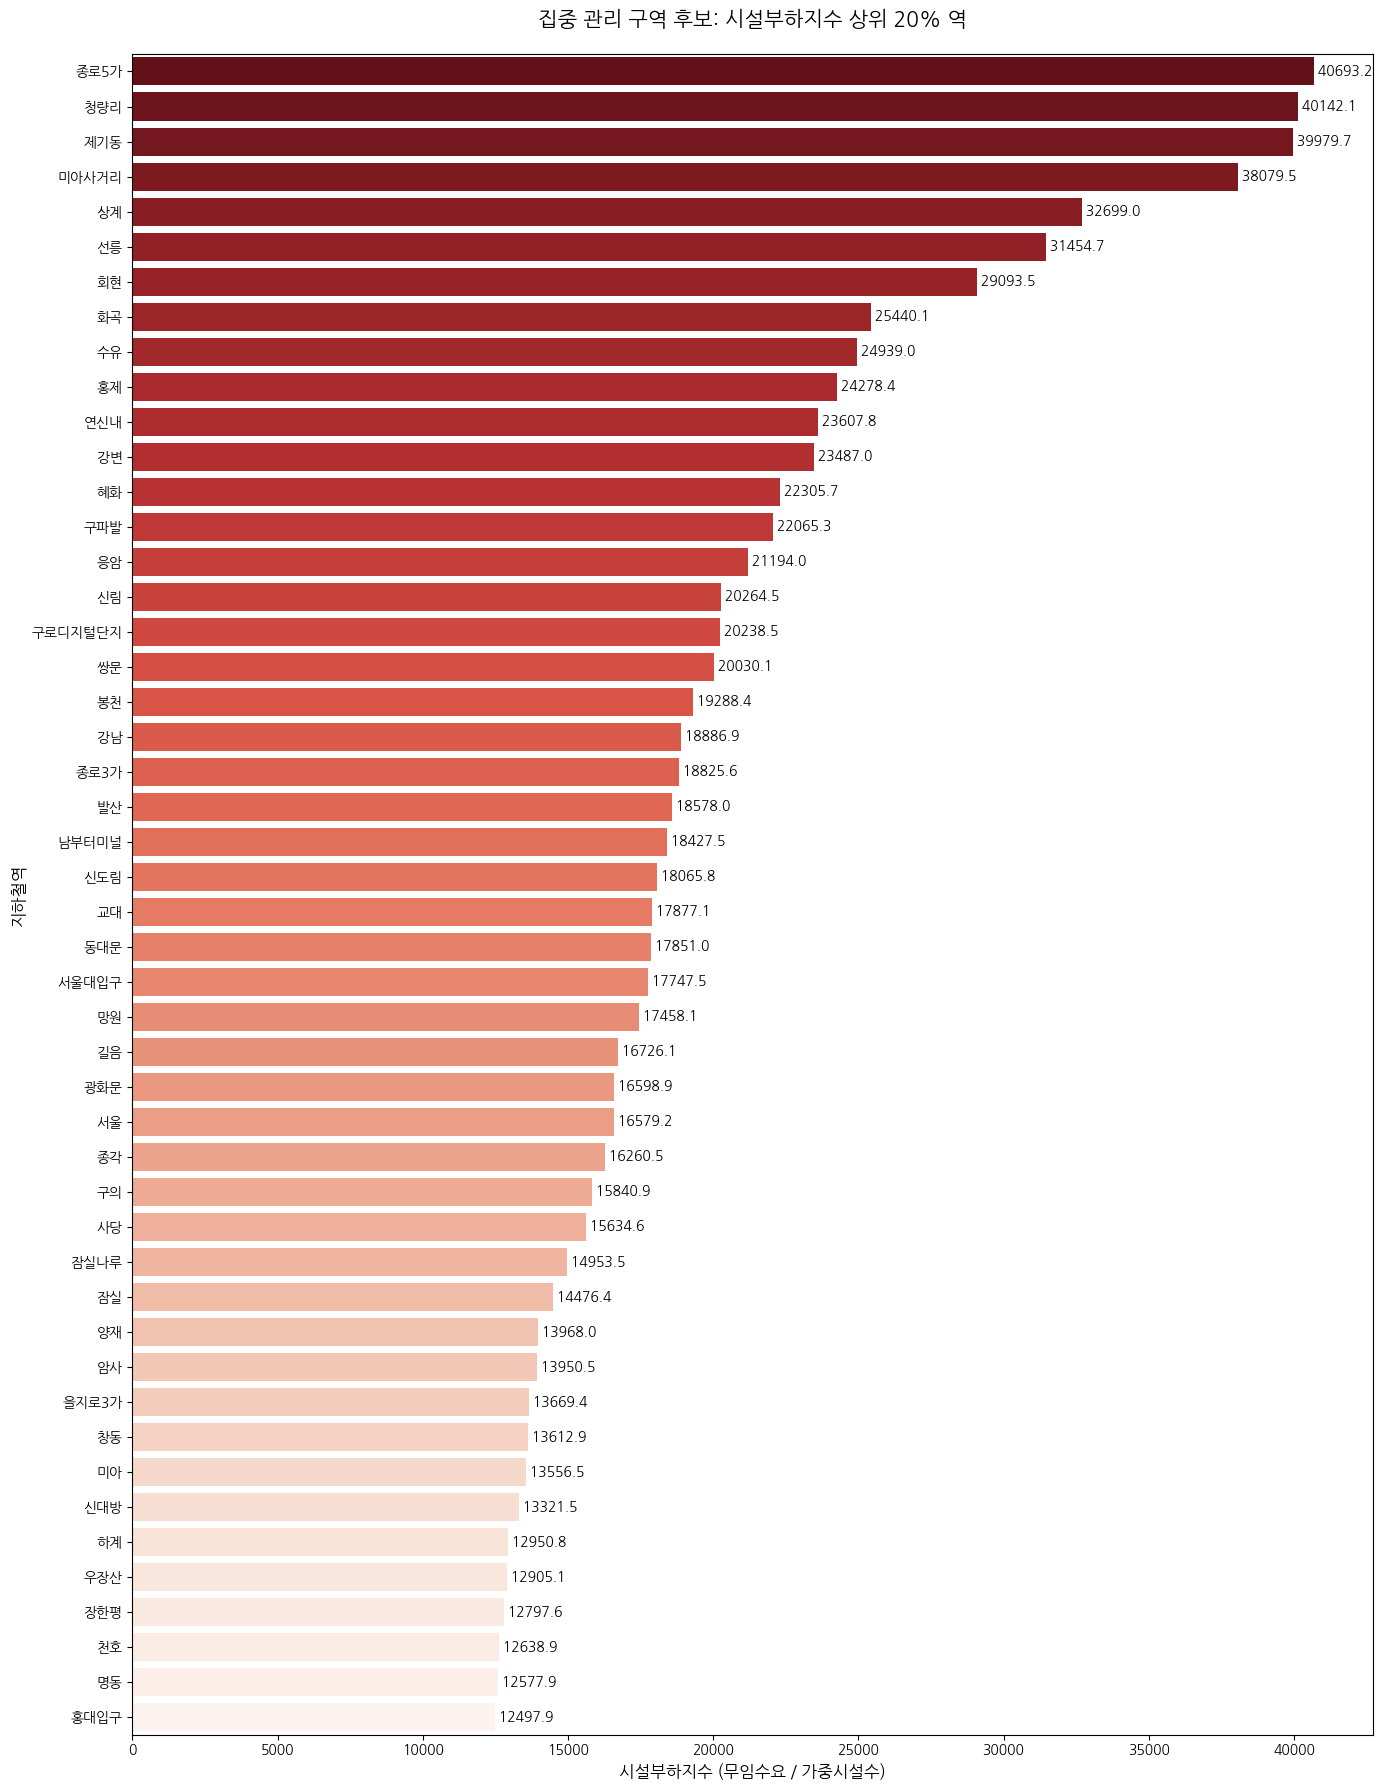

In [34]:
# 가중치 적용 O , 상위 20%역 시각화
plt.figure(figsize=(14, 18))

sns.barplot(
    data=top_20_df,
    x='시설부하지수',
    y='지하철역',
    hue='지하철역',
    palette='Reds_r',
    legend=False
)

plt.title('집중 관리 구역 후보: 시설부하지수 상위 20% 역', fontsize=15, pad=20)
plt.xlabel('시설부하지수 (무임수요 / 가중시설수)', fontsize=12)
plt.ylabel('지하철역', fontsize=12)

for i, val in enumerate(top_20_df['시설부하지수']):
    plt.text(val, i, f' {val:.1f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

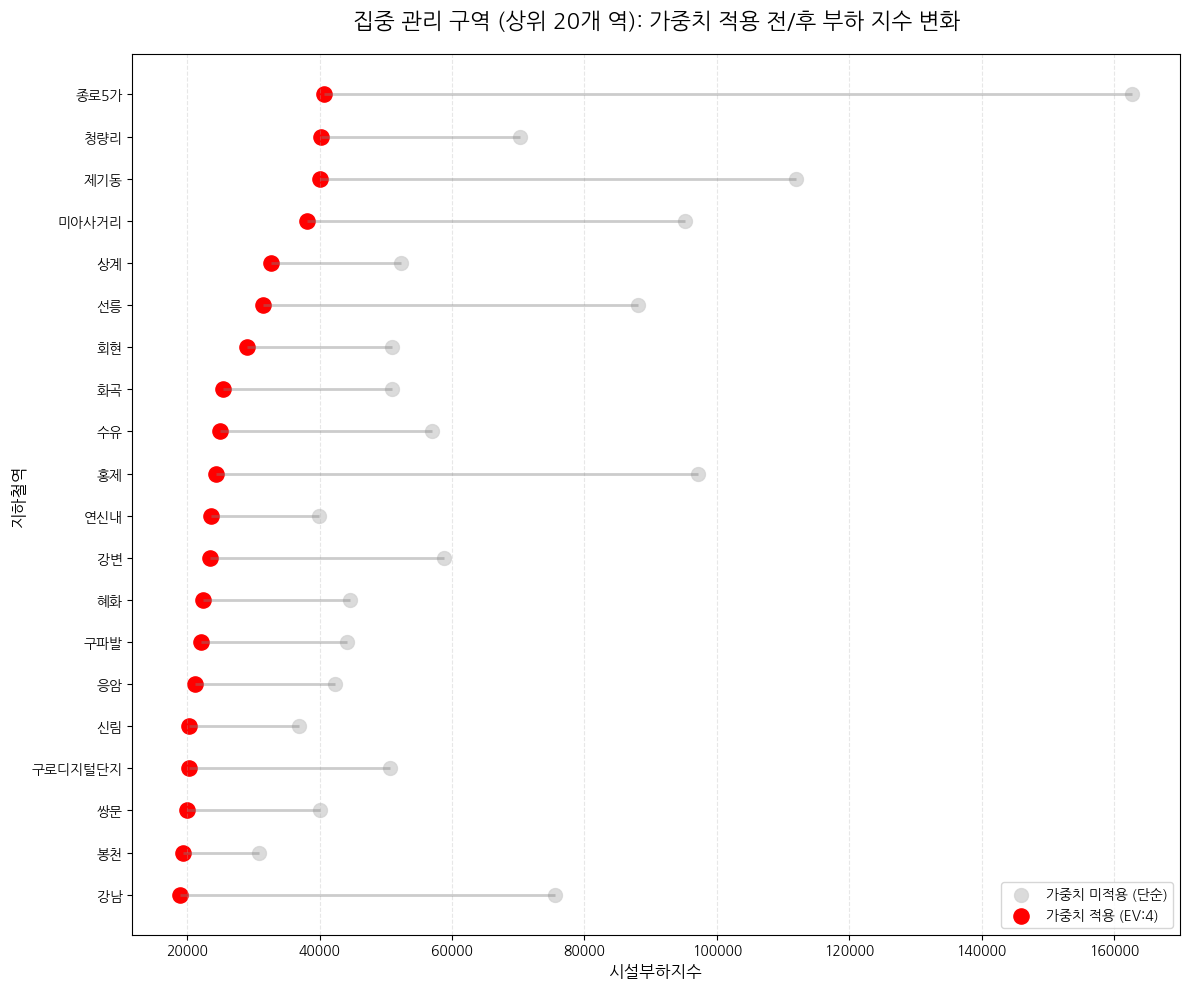

In [44]:
# 상위 20개 추출 후 순서를 뒤집어서 위에서부터 큰 값이 오게 하기
df_plot = comparison_df.head(20).iloc[::-1].copy()

# 상위 20개 역 가중치 전/후 시설부하지수 변화 시각화
plt.figure(figsize=(12, 10))

# 배경에 회색 점선
plt.hlines(y=df_plot['지하철역'], xmin=df_plot['no_weight_시설부하지수'], 
           xmax=df_plot['시설부하지수'], color='grey', alpha=0.4, linewidth=2)

# 가중치 미적용 지수 (회색)
plt.scatter(df_plot['no_weight_시설부하지수'], df_plot['지하철역'], 
            color='lightgrey', alpha=0.8, s=100, label='가중치 미적용 (단순)')

# 가중치 적용 지수 (빨간색)
plt.scatter(df_plot['시설부하지수'], df_plot['지하철역'], 
            color='red', alpha=1, s=120, label='가중치 적용 (EV:4)')

plt.title('집중 관리 구역 (상위 20개 역): 가중치 적용 전/후 부하 지수 변화', fontsize=16, pad=20)
plt.xlabel('시설부하지수', fontsize=12)
plt.ylabel('지하철역', fontsize=12)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.3)

# 수치 변화 강조 (+값 표시)
for i, (idx, row) in enumerate(df_plot.iterrows()):
    diff = row['시설부하지수'] - row['no_weight_시설부하지수']
    if diff > 0:
        plt.text(row['시설부하지수'] + 0.5, i, f'+{diff:.1f}', 
                 va='center', color='red', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()